# Project assignment 3

The objective of this project is to explore the pre-trained Whisper model. In this exercise, we utilize recorded Finnish speech, encompassing both clear, standard language and informal spoken language (slang/dialect). Some of the recordings have been intentionally made indistinct or muffled. The purpose of these recordings is to evaluate the Whisper model's robustness and its ability to accurately recognize various speaking styles and speech qualities.

The Whisper model was developed by OpenAI, and its architecture is a Transformer-based encoder-decoder model. It is designed to handle background noise and indistinct speech more effectively than traditional speech recognition models.

The process begins by importing the required libraries and loading the audio file for processing.

In [31]:
import torch
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# Set the audio filename - update this to your actual filename
audio_file = "Ilkan_nauhoitukset/Ilkan_puhe4.wav"

In [32]:
# Load audio file
y, sr = librosa.load(audio_file, sr=16000)

# Display audio for playback
print("Play the audio:")
display(Audio(y, rate=sr))

# Print audio statistics
duration = librosa.get_duration(y=y, sr=sr)
print(f"\nAudio Statistics:")
print(f"Duration: {duration:.2f} seconds")
print(f"Sample rate: {sr} Hz")

Play the audio:



Audio Statistics:
Duration: 16.14 seconds
Sample rate: 16000 Hz


We visualized the audio using two primary methods. The Waveform illustrates the amplitude variations over time, revealing pauses and volume shifts in the speech. The Mel-frequency Spectrogram provides a representation of the frequency spectrum, adjusted to mimic human hearing. Brighter colors in the spectrogram indicate higher intensity at specific frequencies. These visualizations help us assess the recording's quality and clarity before processing it with the model.

Instead of processing raw audio waves, Whisper converts input into a Mel-spectrogram. In this visualization, the x-axis represents time, the y-axis represents frequency, and the color intensity (decibels) represents the energy/volume of the signal. This format is superior for neural networks because it transforms a complex, one-dimensional audio signal into a structured, two-dimensional 'image.' This allows the Transformer architecture to apply powerful pattern recognition techniques, focusing on the human-audible frequency ranges that are most relevant for speech interpretation.

In [ ]:
%%sql


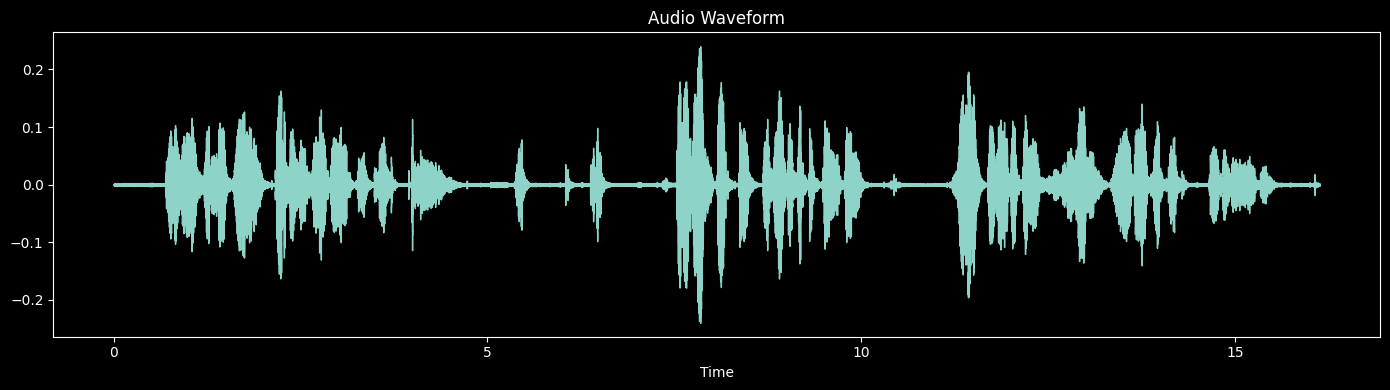

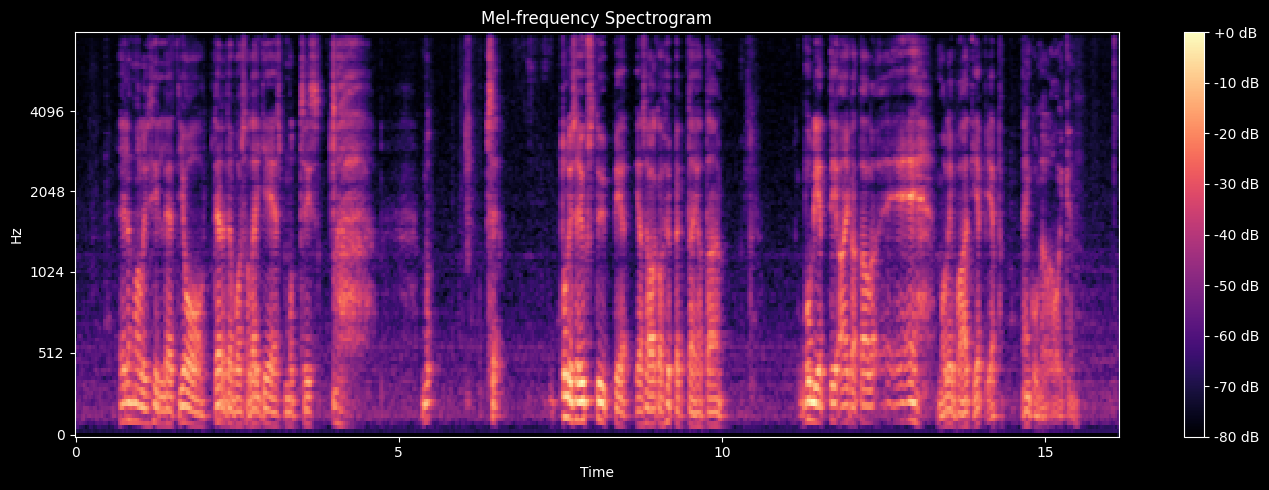

In [33]:
# Plot waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Audio Waveform')
plt.tight_layout()
plt.show()

# Create mel spectrogram
plt.figure(figsize=(14, 5))
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, y_axis='mel', x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency Spectrogram')
plt.tight_layout()
plt.show()

We utilized the large version of the Whisper model. While it demands more computational power—leveraging GPU acceleration where available—it offers significantly higher accuracy in recognizing nuances and complex spoken Finnish compared to smaller versions like 'tiny' or 'base'. The transcription process was divided into two stages. First, the Whisper model generated the Finnish transcription. Subsequently, we compared Whisper’s built-in translation capability with a dedicated Finnish-to-English translation model (MarianMT). This approach aims to achieve the most natural and accurate translation, even in challenging speech scenarios.

In [34]:
# Initialize the model
model_size = "large"  # Options: tiny, base, small, medium, large
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.mps.is_available() else "cpu"
print(f"Using device: {device}")

# Load model and processor
print(f"Loading Whisper {model_size} model...")
model_name = f"openai/whisper-{model_size}"
processor = WhisperProcessor.from_pretrained(model_name)
model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)

# Set the language to Finnish
forced_decoder_ids = processor.get_decoder_prompt_ids(language="fi", task="transcribe")

# Process with WhisperProcessor
print("Processing audio...")
input_features = processor(
    y, 
    sampling_rate=sr, 
    return_tensors="pt"
).input_features.to(device)

# Generate the transcription
print("Generating transcription...")
with torch.no_grad():
    generated_ids = model.generate(
        input_features,
        language="fi",
        task="transcribe"
    )

# Decode the generated IDs
transcription = processor.batch_decode(
    generated_ids, 
    skip_special_tokens=True
)[0]

print("\nFINNISH TRANSCRIPTION:")
print("="*50)
print(transcription)

Using device: cpu
Loading Whisper large model...


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Processing audio...
Generating transcription...

FINNISH TRANSCRIPTION:
 Eilen mä olin silleen, että joo, tieten voisi olla jees, mut siis... Tulis se yks tyyppi ja se alkoi hypöttää jotain. Budjettiaikatailla oli eeh, mä olin vaan et jeb jeb, en kuunnella oikein.


In [35]:
# Set the task to translate
forced_decoder_ids_translate = processor.get_decoder_prompt_ids(language="fi", task="translate")

# Generate the translation
print("Generating English translation...")
with torch.no_grad():
    generated_ids = model.generate(
        input_features,
        language="en",
        task="transcribe"
    )

# Decode the generated IDs
translation = processor.batch_decode(
    generated_ids, 
    skip_special_tokens=True
)[0]

print("\nENGLISH TRANSLATION:")
print("="*50)
print(translation)

Generating English translation...

ENGLISH TRANSLATION:
 Yesterday I was like, yeah, Tertevoisa could be a yes, but... But then one guy came along and started to say something. Budget time, I was like, ehh... I was like, yep yep, I'm not listening.


In [36]:
from transformers import MarianMTModel, MarianTokenizer

# Load a dedicated Finnish to English translation model
model_name = "Helsinki-NLP/opus-mt-fi-en"
translation_tokenizer = MarianTokenizer.from_pretrained(model_name)
translation_model = MarianMTModel.from_pretrained(model_name)

# Translate the Finnish transcription
inputs = translation_tokenizer(transcription, return_tensors="pt")
translated = translation_model.generate(**inputs)
better_translation = translation_tokenizer.decode(translated[0], skip_special_tokens=True)

print("BETTER ENGLISH TRANSLATION:")
print("="*50)
print(better_translation)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

BETTER ENGLISH TRANSLATION:
Yesterday I was like, yeah, sure could be all right, but I mean, there's this guy, and he started jumping something.


# Summary

Our observations indicate that the Whisper model performs exceptionally well with clear speech. However, in indistinct recordings, it relies more on context to 'guess' the words. The large model successfully mitigates many errors that smaller models would likely produce.